# KQ Smoothness Illustration

This notebook creates three example functions with increasing smoothness. The roughest function is a trajectory from the Brownian motion kernel, and the smoother functions use Fourier coefficients with faster decay. The figure is used in the MMD talk to illustrate that kernel quadrature rates depend on the smoothness of the integrand and the kernel.

In [11]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.4,
})

In [12]:
rng = np.random.default_rng(7)


def normalize(y):
    y = y - y.mean()
    return y / np.max(np.abs(y))


def brownian_motion_kernel_path(x):
    """Sample from the Brownian motion kernel K(x, x') = min(x, x')."""
    increments = rng.normal(scale=np.sqrt(np.diff(x, prepend=x[0])))
    return normalize(np.cumsum(increments))


def fourier_function(x, decay, n_terms=70):
    """Random Fourier series with a prescribed coefficient decay."""
    y = np.zeros_like(x)
    for k in range(1, n_terms + 1):
        phase_1, phase_2 = rng.uniform(0, 2 * np.pi, size=2)
        amp = decay(k)
        y += amp * np.sin(2 * np.pi * k * x + phase_1)
        y += 0.75 * amp * np.cos(2 * np.pi * k * x + phase_2)
    return normalize(y)


x = np.linspace(0, 1, 1800)

functions = [
    (r"$s=0$", brownian_motion_kernel_path(x), "#b94b48"),
    (r"$s=2$", fourier_function(x, lambda k: k ** -2.8), "#2f7f5f"),
    (r"$s=\infty$", fourier_function(x, lambda k: np.exp(-(k / 5.0) ** 2)), "#2d68a8"),
]

PosixPath('/home/zongchen/mini_mmd/figures/kq_smoothness_illustration.pdf')

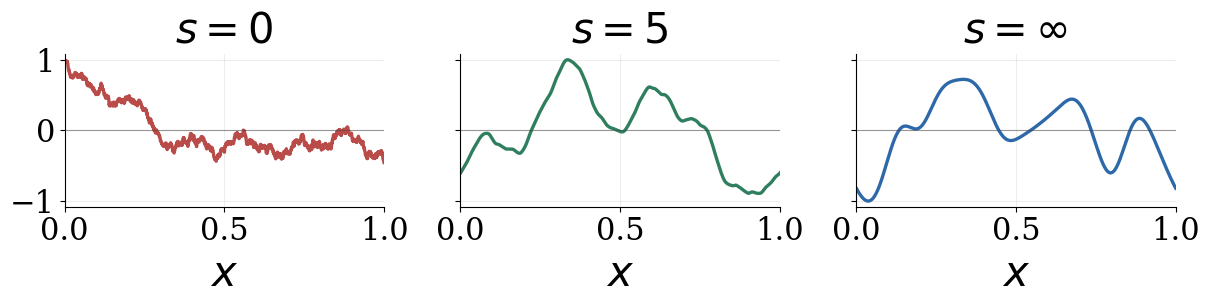

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.15), sharex=True, sharey=True)

for ax, (title, y, color) in zip(axes, functions):
    ax.plot(x, y, color=color)
    ax.axhline(0, color="0.25", lw=0.8, alpha=0.5)
    ax.set_title(title, pad=8, fontsize=30)
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.08, 1.08)
    ax.set_xlabel(r"$x$", fontsize=30)
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(axis='both', which='major', labelsize=22)

fig.tight_layout(w_pad=2.0)

out = Path("/home/zongchen/mini_mmd/figures/kq_smoothness_illustration.pdf")
fig.savefig(out, bbox_inches="tight")
out